In [ ]:
#Imports
import os
import numpy as np
import tkinter as tk
from tkinter import filedialog
import glob
import calcFunctions as calcFunc
import inputsOutputsFunctions as inpOutsFunc
from pathlib import Path
from tqdm import tqdm

In [2]:
def select_root_path()->str:
    """Opens a single dialog to select the top-level ROOT_PATH."""
    root_path = filedialog.askdirectory(title='Select the Top-Level ROOT_PATH Folder')
    return root_path

In [3]:
# Create Tk root
root = tk.Tk()
# Hide the main window
root.withdraw()
root.call('wm', 'attributes', '.', '-topmost', True)
ROOT_PATH = select_root_path()

In [ ]:
#Specific grain boundary function
def grain_boundaries(GB_file_path:str, GI_file_path:str,save_path:str, pixel_index:int, GB_colour:str, GI_colour:str, datatype:str)->float:
    """
    Fits Gaussian to GB and GI data, plots the results, saves the plot, 
    and writes the analysis data to a text file.
    """
    # Pixel number corresponds to the 'pixels' value (1 to 5)
    pixels = int(pixel_index)

    # Perform fitting
    GB_x_raw_1, GB_y_raw_1, GB_x_1, GB_y_1, GB_peak_1, GB_fwhm_1 = calcFunc.fit_gaussian(inpOutsFunc.loadtxtFile(GB_file_path))
    GI_x_raw_1, GI_y_raw_1, GI_x_1, GI_y_1, GI_peak_1, GI_fwhm_1 = calcFunc.fit_gaussian(inpOutsFunc.loadtxtFile(GB_file_path))

    #Working out peak difference (GI-GB)
    peak_diff_1 = GI_peak_1 - GB_peak_1


    inpOutsFunc.storeAnalysis(GB_peak_1,GB_fwhm_1,0,0,GI_peak_1,GI_fwhm_1,0,0,peak_diff_1,save_path,pixels)
    
    # #Adjusting arrays to give results in mV
    GB_x_raw = [round(x*1000, 4) if not np.isnan(x) else np.nan for x in GB_x_raw_1]
    GI_x_raw = [round(x*1000, 4) if not np.isnan(x) else np.nan for x in GI_x_raw_1]
    GB_x_fit=[round(x*1000, 4) if not np.isnan(x) else np.nan for x in GB_x_1]
    GI_x_fit=[round(x*1000, 4) if not np.isnan(x) else np.nan for x in GI_x_1]

    # # Plotting functions: 
    inpOutsFunc.generateFigures(GB_x_raw,GB_x_fit,GI_x_raw,GI_x_fit,GB_y_raw_1,GB_y_1,GI_y_raw_1,GI_y_1,GB_colour,GI_colour,save_path,datatype,pixels)            
    return peak_diff_1,GB_peak_1, GI_peak_1

In [ ]:
Colours={"unpassivated":{'colour1': "#5CBBFF", 'colour2': "#003357"},
         "passivated":{'colour1': "#D69AAB", 'colour2': "#8D1730"}}

In [ ]:
filetype = ".txt"
directories=[]
for i in glob.glob(f"{ROOT_PATH}/**/*{filetype}",recursive=True):
    filePath = Path(i)
    #skips the directory named Plots
    if filePath.parent.parent.parent.name=='Plots': continue
    directories.append(filePath.parent)
directories = sorted(set(directories))

In [ ]:
all_results = {}
for i in tqdm(range(0,len(directories)-1,2)):
    if(len(glob.glob(f"{directories[i]}/*.txt"))!=len(glob.glob(f"{directories[i+1]}/*.txt"))):
        raise ValueError("Different number of GI and GB files")
    if(directories[i].parent.parent.name=='Plots'): continue
    parent = directories[i].parent.parent.name
    dataType = directories[i].parent.name
    measureType = directories[i].name
    save_path = os.path.join(ROOT_PATH, 'Plots', parent, dataType)
    os.makedirs(save_path, exist_ok=True)
    
    y_peaks_adjusted = []
    GB_peaks_adjusted = []
    GI_peaks_adjusted = []
    
    for GB_file, GI_file in zip(sorted(glob.glob(f"{directories[i]}/*{filetype}")),sorted(glob.glob(f"{directories[i+1]}/*{filetype}"))):
        # use file name to find the index
        index = int(Path(GB_file).name.split('.')[0])
        
        y_peaks, GB_peaks, GI_peaks = grain_boundaries(GB_file,GI_file,save_path,index,Colours[parent.lower()]["colour1"],Colours[parent.lower()]["colour2"],measureType)
        y_peaks_adjusted.append(round(y_peaks * 1000, 4))
        GB_peaks_adjusted.append(round(GB_peaks * 1000, 4))
        GI_peaks_adjusted.append(round(GI_peaks * 1000, 4))

        
    all_results[f"{parent}_{dataType}"]={"y_peaks_adjusted":y_peaks_adjusted,"GB_peaks_adjusted":GB_peaks_adjusted,"GI_peaks_adjusted":GI_peaks_adjusted}

In [ ]:
passivatedVals ={i:all_results[i] for i in all_results.keys() if i.split('_')[0]=="passivated"}
unpassivatedVals ={i:all_results[i] for i in all_results.keys() if i.split('_')[0]!="passivated"}

In [ ]:
averagedVals={**calcFunc.calcAverage(passivatedVals,"passivated"),**calcFunc.calcAverage(unpassivatedVals,"Unpassivated")}
averagedVals["passivated"] = {**averagedVals["passivated"],**{"GB_color":"#D69AAB","GI_color":"#8D1730"}}
averagedVals["unpassivated"] = {**averagedVals["unpassivated"],**{"GB_color":"#5CBBFF","GI_color":"#003357"}}

ValueError: 'x' and 'y' must have the same size

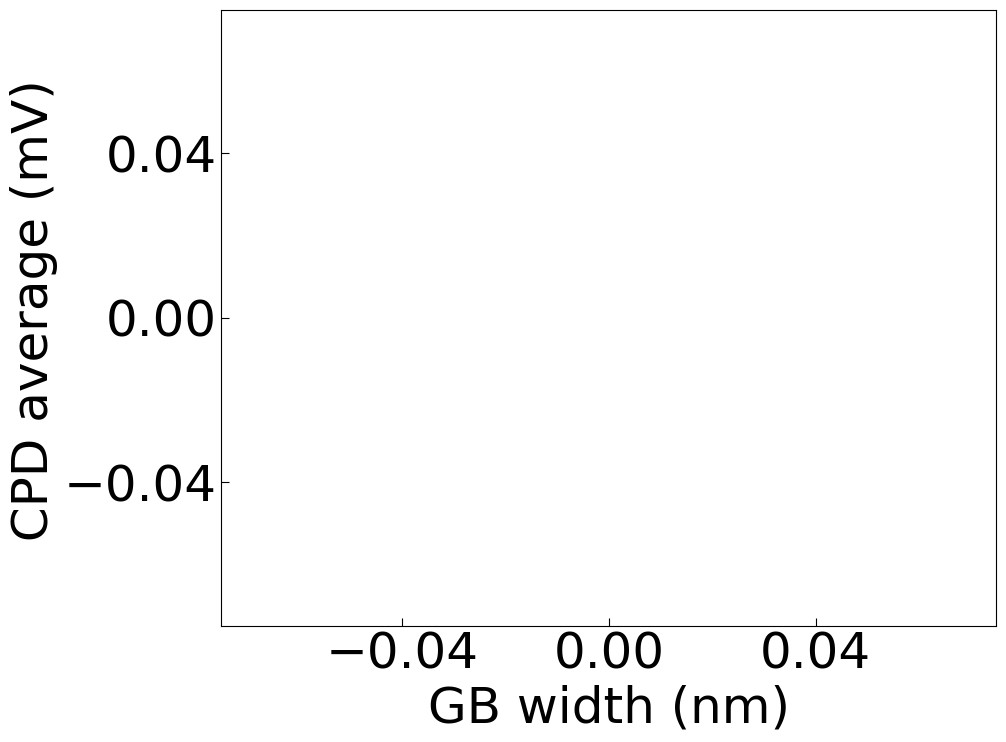

In [ ]:
passivatedData = averagedVals["passivated"]
inpOutsFunc.GIGBPlot(passivatedData["avgGB"],passivatedData["avgGB_error"],passivatedData["GB_color"],passivatedData["avgGI"],passivatedData["avgGI_error"],passivatedData["GI_color"],"passivated","apple")

ValueError: 'x' and 'y' must have the same size

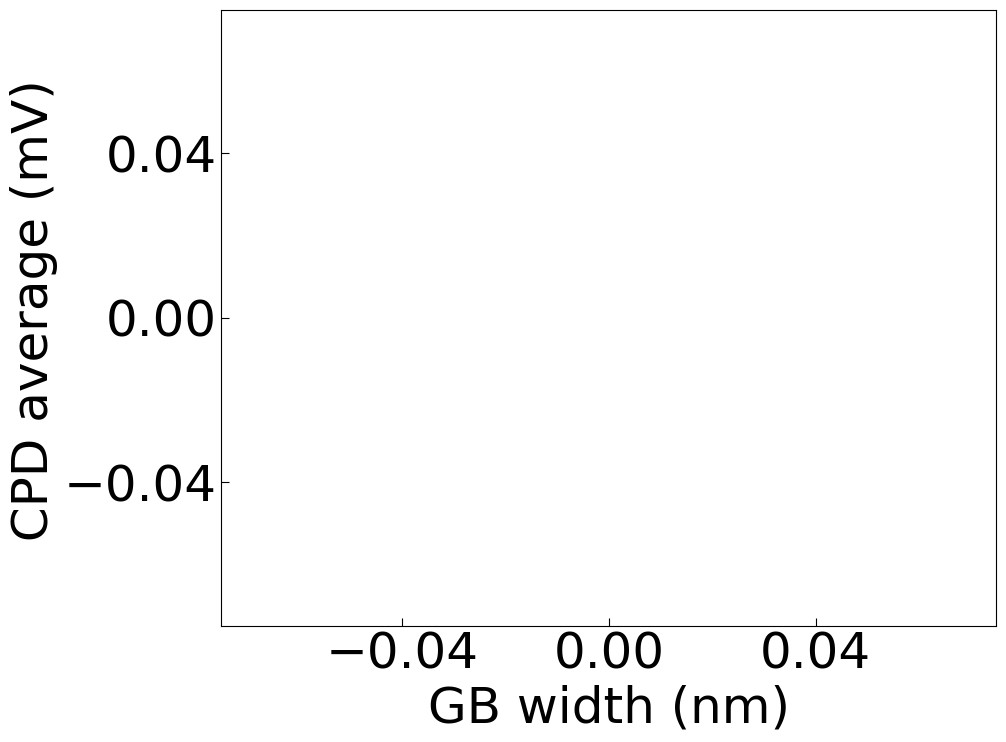

In [ ]:
Unpassivated = averagedVals["unpassivated"]
inpOutsFunc.GIGBPlot(Unpassivated["avgGB"],Unpassivated["avgGB_error"],Unpassivated["GB_color"],Unpassivated["avgGI"],Unpassivated["avgGI_error"],Unpassivated["GI_color"],"passivated","apple")